In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling1D, Conv1D, Attention, Embedding, Dense
from tensorflow.keras.models import Model

In [3]:
X_train = np.load('sample_data/training.npy')
y_train = np.load('sample_data/training_labels.npy')
X_test = np.load('sample_data/test.npy')
y_test = np.load('sample_data/test_labels.npy')
embedding_matrix = np.load('sample_data/embedding_matrix.npy')

#Attention Dot-product Luong-style

In [4]:
# Số lượng vocab trong bộ dữ liệu (xem ở data pre-processing)
vocab_size = 52145

# Đầu vào của mạng là chuỗi với độ dài 300
input = tf.keras.Input(shape=(300,)) #, dtype='int32')

# Embedding
embedding = Embedding(vocab_size,
            output_dim=int(3e2),
            weights=[embedding_matrix], # Embedding weght sau khi pre-trained Word2vec (Word Representaiotn)
            trainable=True)

# Query embeddings of shape [batch_size, Tq, dimension].
query_embeddings = embedding(input)
# Value embeddings of shape [batch_size, Tv, dimension].
value_embeddings = embedding(input)

query_value_attention_seq = tf.keras.layers.Attention()([query_embeddings, value_embeddings])

query_encoding = tf.keras.layers.GlobalAveragePooling1D()(query_embeddings)

query_value_attention = tf.keras.layers.GlobalAveragePooling1D()(query_value_attention_seq)

input_layer = tf.keras.layers.Concatenate()([query_encoding, query_value_attention])

clf = Dense(300,activation="relu")(input_layer)
clf = Dense(1,activation="sigmoid")(clf)

model = Model(input, clf)

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 300)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 300, 300)             1564350   ['input_1[0][0]',             
                                                          0          'input_1[0][0]']             
                                                                                                  
 attention (Attention)       (None, 300, 300)             0         ['embedding[0][0]',           
                                                                     'embedding[1][0]']           
                                                                                              

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)

history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1)

Epoch 1/100
22/22 [==============================] - 9s 283ms/step - loss: 0.6751 - accuracy: 0.5681 - val_loss: 0.7808 - val_accuracy: 0.0516
Epoch 2/100
22/22 [==============================] - 5s 210ms/step - loss: 0.6694 - accuracy: 0.5715 - val_loss: 0.7846 - val_accuracy: 0.0684
Epoch 3/100
22/22 [==============================] - 5s 215ms/step - loss: 0.6639 - accuracy: 0.5777 - val_loss: 0.7837 - val_accuracy: 0.0928
Epoch 4/100
22/22 [==============================] - 6s 255ms/step - loss: 0.6587 - accuracy: 0.5882 - val_loss: 0.7810 - val_accuracy: 0.1224
Epoch 5/100
22/22 [==============================] - 5s 212ms/step - loss: 0.6535 - accuracy: 0.5999 - val_loss: 0.7743 - val_accuracy: 0.1632
Epoch 6/100
22/22 [==============================] - 6s 262ms/step - loss: 0.6484 - accuracy: 0.6115 - val_loss: 0.7691 - val_accuracy: 0.2092
Epoch 7/100
22/22 [==============================] - 4s 203ms/step - loss: 0.6432 - accuracy: 0.6252 - val_loss: 0.7606 - val_accuracy: 0.2548

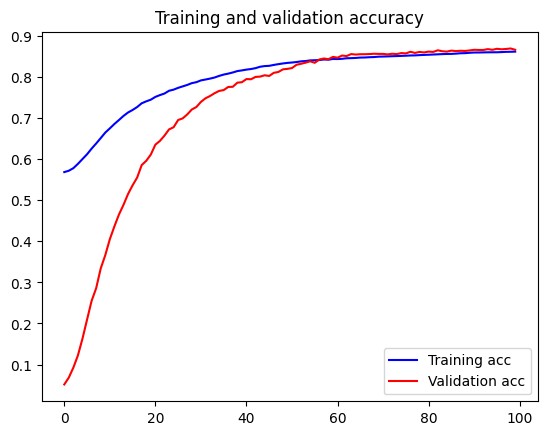

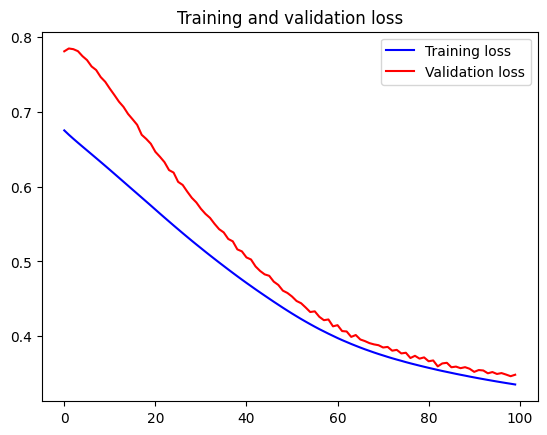

In [6]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [7]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 1s 56ms/step - loss: 0.3424 - accuracy: 0.8559

ACCURACY: 0.855874240398407
LOSS: 0.34237322211265564


In [8]:
model.save('/model_attention_nlp.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
